In [61]:
#Carregando bibliotecas e datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

users = pd.read_csv("../data/users_dataset.csv")
user_plan = pd.read_csv("../data/user_plan.csv")
user_app = pd.read_csv("../data/user_app.csv")
activities = pd.read_csv("../data/activities_dataset.csv")
weekly_visits = pd.read_csv("../data/weekly_gym_visits_aggregated_dataset.csv")
challenges = pd.read_csv("../data/challenges_dataset.csv")
desafio_usuario = pd.read_csv("../data/desafio_usuario_dataset.csv")

##Entendendo o tamanho de cada dataset

In [62]:
#Tamanho de cada Dataset
print("Users:", users.shape)
print("User Plan:", user_plan.shape)
print("User App:", user_app.shape)
print("Activities:", activities.shape)
print("Weekly Visits:", weekly_visits.shape)
print("Challenges:", challenges.shape)
print("desafio Usuário:", desafio_usuario.shape)

Users: (1000, 4)
User Plan: (1229, 3)
User App: (12285, 4)
Activities: (13144, 9)
Weekly Visits: (9735, 4)
Challenges: (50, 4)
desafio Usuário: (500, 4)


In [63]:
#Sumário das linhas e colunas de cada Dataset
datasets = {
    'users': users,
    'user_plan': user_plan,
    'user_app': user_app,
    'activities': activities,
    'weekly_visits': weekly_visits,
    'challenges': challenges,
    'desafio_usuario': desafio_usuario
}

summary = pd.DataFrame({
    'dataset':datasets.keys(),
    'rows': [df.shape[0] for df in datasets.values()],
    'columns': [df.shape[1] for df in datasets.values()]
})

summary

,dataset,rows,columns
0,users,1000,4
1,user_plan,1229,3
2,user_app,12285,4
3,activities,13144,9
4,weekly_visits,9735,4
5,challenges,50,4
6,desafio_usuario,500,4



##Entendendo o User Dataset

In [64]:
#Conhecendo o Dataset
users.head()

,user_id,age_group,gender,distance_to_gym
0,1,26-35,Male,13.09
1,2,51+,Female,12.35
2,3,36-50,Female,45.31
3,4,26-35,Female,12.48
4,5,18-25,Female,13.60


In [65]:
#Dados Estatísticos Iniciais
users.info()
users.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          1000 non-null   int64  
 1   age_group        1000 non-null   str    
 2   gender           1000 non-null   str    
 3   distance_to_gym  1000 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 31.4 KB


,user_id,distance_to_gym
count,1000.000000,1000.000000
mean,500.500000,25.120300
std,288.819436,14.533688
min,1.000000,0.000000
25%,250.750000,13.070000
50%,500.500000,25.030000
75%,750.250000,37.955000
max,1000.000000,49.890000


In [66]:
#Ocorrências dentro da coluna
users['age_group'].unique()

<StringArray>
['26-35', '51+', '36-50', '18-25']
Length: 4, dtype: str

In [67]:
#Ocorrências dentro da coluna
users['gender'].unique()

<StringArray>
['Male', 'Female', 'Non-binary']
Length: 3, dtype: str

In [68]:
#Sumário das colunas Strings
users.select_dtypes(include=['object', 'string'])

for col in users.select_dtypes(include=['object','string']).columns:
    print(f'\n==== Coluna: {col} ====')
    print(users[col].value_counts())


==== Coluna: age_group ====
age_group
26-35    393
18-25    319
36-50    188
51+      100
Name: count, dtype: int64

==== Coluna: gender ====
gender
Male          484
Female        457
Non-binary     59
Name: count, dtype: int64


In [69]:
#Verificando nulos
users.isnull().sum()

user_id            0
age_group          0
gender             0
distance_to_gym    0
dtype: int64

In [70]:
users[users.duplicated()]

,user_id,age_group,gender,distance_to_gym


Falar do dataset 'users' que não tem duplicadas.

##Entendendo o User Plan Dataset

In [71]:
#Conhecendo o Dataset
user_plan.head()

,user_id,data_inicio,plano
0,1,2023-02-08,Grátis
1,2,2023-01-22,Grátis
2,3,2023-05-06,Grátis
3,3,2023-10-17,Pagante
4,4,2023-01-12,Grátis


In [72]:
#Dados Estatísticos Iniciais
user_plan.info()
user_plan.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1229 non-null   int64
 1   data_inicio  1229 non-null   str  
 2   plano        1229 non-null   str  
dtypes: int64(1), str(2)
memory usage: 28.9 KB


,user_id
count,1229.000000
mean,490.320586
std,289.282623
min,1.000000
25%,240.000000
50%,487.000000
75%,741.000000
max,1000.000000


In [73]:
#Ocorrências dentro da coluna
user_plan['data_inicio'].unique()

<StringArray>
['2023-02-08', '2023-01-22', '2023-05-06', '2023-10-17', '2023-01-12',
 '2023-11-15', '2023-03-09', '2023-09-26', '2023-03-13', '2023-11-14',
 ...
 '2023-09-07', '2023-08-09', '2023-06-09', '2023-04-28', '2023-05-27',
 '2023-09-08', '2023-06-07', '2024-08-03', '2023-09-13', '2023-08-17']
Length: 264, dtype: str

In [74]:
#Ocorrências dentro da coluna
user_plan['plano'].unique()

<StringArray>
['Grátis', 'Pagante']
Length: 2, dtype: str

In [75]:
#Sumário das colunas Strings
user_plan.select_dtypes(include=['object','string'])

for col in user_plan.select_dtypes(include=['object','string']).columns:
    print(f'\n==== Coluna: {col} ====')
    print(user_plan[col].value_counts())


==== Coluna: data_inicio ====
data_inicio
2023-02-14    19
2023-01-07    17
2023-01-17    16
2023-01-24    15
2023-01-05    15
              ..
2023-05-27     1
2023-09-08     1
2024-08-03     1
2023-09-13     1
2023-08-17     1
Name: count, Length: 264, dtype: int64

==== Coluna: plano ====
plano
Grátis     1000
Pagante     229
Name: count, dtype: int64


In [76]:
#Contagem de ocorrências dentro da coluna
user_plan['data_inicio'].count()

np.int64(1229)

In [77]:
#Verificando nulos
user_plan.isnull().sum()

user_id        0
data_inicio    0
plano          0
dtype: int64

In [78]:
user_plan[user_plan.duplicated()]

,user_id,data_inicio,plano
98,73,2023-12-19,Pagante
100,73,2024-01-23,Pagante


In [79]:
user_plan[user_plan.duplicated(keep=False)]

,user_id,data_inicio,plano
97,73,2023-12-19,Pagante
98,73,2023-12-19,Pagante
99,73,2024-01-23,Pagante
100,73,2024-01-23,Pagante


Falar do dataset 'user_plan' que tem 2 duplicatas.

##Entendendo o User App Dataset

In [80]:
#Conhecendo o Dataset
user_app.head()

,user_id,checkin,atividade,post
0,661,2024-11-09,Crossfit,0
1,104,2024-08-10,Meditação,0
2,755,2023-11-10,Caminhada,0
3,462,2024-11-24,Caminhada,1
4,743,2024-01-25,Caminhada,0


In [81]:
#Dados Estatísticos Iniciais
user_app.info()
user_app.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12285 entries, 0 to 12284
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    12285 non-null  int64
 1   checkin    12285 non-null  str  
 2   atividade  12285 non-null  str  
 3   post       12285 non-null  int64
dtypes: int64(2), str(2)
memory usage: 384.0 KB


,user_id,post
count,12285.000000,12285.000000
mean,494.779080,0.424013
std,287.121347,0.494212
min,1.000000,0.000000
25%,246.000000,0.000000
50%,498.000000,0.000000
75%,742.000000,1.000000
max,1000.000000,1.000000


In [82]:
#Ocorrências dentro da coluna
user_app['checkin'].unique()

<StringArray>
['2024-11-09', '2024-08-10', '2023-11-10', '2024-11-24', '2024-01-25',
 '2023-02-14', '2024-10-24', '2023-04-27', '2023-05-02', '2024-04-26',
 ...
 '2024-04-03', '2024-04-18', '2023-09-30', '2024-10-16', '2023-07-28',
 '2023-07-25', '2023-07-29', '2024-03-24', '2023-03-28', '2023-10-16']
Length: 700, dtype: str

In [83]:
#Ocorrências dentro da coluna
user_app['atividade'].unique()

<StringArray>
['Crossfit', 'Meditação', 'Caminhada', 'Bike Indoor', 'Corrida']
Length: 5, dtype: str

In [84]:
#Sumário das colunas Strings
user_app.select_dtypes(include=['object','string'])

for col in user_app.select_dtypes(include=['object','string']).columns:
    print(f'\n==== Coluna: {col} ====')
    print(user_app[col].value_counts())


==== Coluna: checkin ====
checkin
2023-10-17    39
2024-05-04    38
2023-11-14    38
2024-04-23    38
2024-04-30    37
              ..
2023-03-02     6
2023-02-19     6
2023-07-11     5
2023-02-18     5
2024-10-10     4
Name: count, Length: 700, dtype: int64

==== Coluna: atividade ====
atividade
Caminhada      3786
Bike Indoor    2601
Meditação      2008
Corrida        2004
Crossfit       1886
Name: count, dtype: int64


In [85]:
#Contagem de ocorrências na coluna
user_app['checkin'].count()

np.int64(12285)

In [86]:
#Verificando nulos
user_app.isnull().sum()

user_id      0
checkin      0
atividade    0
post         0
dtype: int64

In [87]:
user_app[user_app.duplicated()]

,user_id,checkin,atividade,post
4727,92,2023-07-16,Bike Indoor,0
4758,676,2023-03-02,Meditação,0
5619,57,2023-10-19,Caminhada,0
5879,799,2024-09-14,Caminhada,0
6822,773,2024-04-30,Caminhada,0
7684,791,2023-11-02,Bike Indoor,0
7784,528,2023-03-22,Crossfit,1
7934,122,2023-06-29,Caminhada,0
8949,86,2023-10-18,Corrida,0
9463,496,2024-08-31,Caminhada,0


In [88]:
user_app[user_app.duplicated(keep=False)]

,user_id,checkin,atividade,post
482,122,2023-06-29,Caminhada,0
549,92,2023-07-16,Bike Indoor,0
640,592,2024-07-30,Bike Indoor,0
705,799,2024-09-14,Caminhada,0
1883,791,2023-11-02,Bike Indoor,0
1950,57,2023-10-19,Caminhada,0
2028,496,2024-08-31,Caminhada,0
2416,196,2024-05-27,Meditação,0
3098,676,2023-03-02,Meditação,0
3403,528,2023-03-22,Crossfit,1


Falar sobre o dataset 'user_app' que tem 24 duplicatas.

##Entendendo o Activities Dataset

In [89]:
#Conhecendo o Dataset
activities.head()

,activity_id,user_id,steps,minutes_meditated,activity_type,date,calories_burned,gym_visit,week
0,1,661,14063,27,Crossfit,2024-11-09,650.59,True,45
1,2,104,881,19,Meditação,2024-08-10,28.51,False,32
2,3,755,2060,5,Caminhada,2023-11-10,104.85,False,45
3,4,462,14677,7,Caminhada,2024-11-24,243.20,False,47
4,5,743,18466,31,Caminhada,2024-01-25,65.13,False,4


In [90]:
#Dados Estatísticos Iniciais
activities.info()
activities.describe()

<class 'pandas.DataFrame'>
RangeIndex: 13144 entries, 0 to 13143
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   activity_id        13144 non-null  int64  
 1   user_id            13144 non-null  int64  
 2   steps              13144 non-null  int64  
 3   minutes_meditated  13144 non-null  int64  
 4   activity_type      13144 non-null  str    
 5   date               13144 non-null  str    
 6   calories_burned    13144 non-null  float64
 7   gym_visit          13144 non-null  bool   
 8   week               13144 non-null  int64  
dtypes: bool(1), float64(1), int64(5), str(2)
memory usage: 834.5 KB


,activity_id,user_id,steps,minutes_meditated,calories_burned,week
count,13144.000000,13144.000000,13144.000000,13144.000000,13144.000000,13144.000000
mean,6572.500000,496.827982,10123.843427,22.307212,363.177006,25.719568
std,3794.490304,287.272363,5245.218712,19.510169,276.720714,14.760510
min,1.000000,1.000000,3.000000,0.000000,10.000000,1.000000
25%,3286.750000,247.000000,6039.750000,0.000000,93.750000,13.000000
50%,6572.500000,502.000000,10149.000000,20.000000,313.618865,25.000000
75%,9858.250000,746.000000,14203.000000,39.000000,596.862500,39.000000
max,13144.000000,1000.000000,19999.000000,59.000000,999.990000,52.000000


In [91]:
#Ocorrências dentro da coluna
activities['activity_type'].unique()

<StringArray>
['Crossfit', 'Meditação', 'Caminhada', 'Bike Indoor', 'Corrida']
Length: 5, dtype: str

In [92]:
#Ocorrências dentro da coluna
activities['date'].unique()

<StringArray>
['2024-11-09', '2024-08-10', '2023-11-10', '2024-11-24', '2024-01-25',
 '2023-02-14', '2024-10-24', '2023-04-27', '2023-05-02', '2024-04-26',
 ...
 '2024-04-03', '2024-04-18', '2023-09-30', '2024-10-16', '2023-07-28',
 '2023-07-25', '2023-07-29', '2024-03-24', '2023-03-28', '2023-10-16']
Length: 700, dtype: str

In [93]:
#Sumário das colunas Strings
activities.select_dtypes(include=['object','string'])

for col in activities.select_dtypes(include=['object','string']).columns:
    print(f'\n==== Coluna: {col} ====')
    print(activities[col].value_counts())


==== Coluna: activity_type ====
activity_type
Caminhada      3881
Bike Indoor    2661
Meditação      2592
Corrida        2074
Crossfit       1936
Name: count, dtype: int64

==== Coluna: date ====
date
2024-05-08    40
2024-04-24    39
2024-03-13    39
2023-11-22    38
2024-01-10    37
              ..
2023-03-02     6
2023-02-19     6
2023-07-11     5
2023-02-18     5
2024-10-10     4
Name: count, Length: 700, dtype: int64


In [94]:
#Contagem de ocorrências na coluna
activities['date'].count()

np.int64(13144)

In [95]:
#Verificando nulos
activities.isnull().sum()

activity_id          0
user_id              0
steps                0
minutes_meditated    0
activity_type        0
date                 0
calories_burned      0
gym_visit            0
week                 0
dtype: int64

In [96]:
activities[activities.duplicated()]

,activity_id,user_id,steps,minutes_meditated,activity_type,date,calories_burned,gym_visit,week


Falar sobre o dataset 'activities'

##Entendendo o Weekly Visits Dataset

In [97]:
#Conhecendo o Dataset
weekly_visits.head()

,user_id,week,weekly_gym_visits,sedentarism_level
0,1,6,1,1
1,1,7,0,0
2,1,11,0,0
3,1,15,2,2
4,1,17,0,0


In [98]:
#Dados Estatísticos Iniciais
weekly_visits.info()
weekly_visits.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9735 entries, 0 to 9734
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   user_id            9735 non-null   int64
 1   week               9735 non-null   int64
 2   weekly_gym_visits  9735 non-null   int64
 3   sedentarism_level  9735 non-null   int64
dtypes: int64(4)
memory usage: 304.3 KB


,user_id,week,weekly_gym_visits,sedentarism_level
count,9735.000000,9735.000000,9735.000000,9735.000000
mean,500.367437,25.686184,0.832357,0.782332
std,286.868398,14.571435,1.154778,0.972699
min,1.000000,1.000000,0.000000,0.000000
25%,253.000000,13.000000,0.000000,0.000000
50%,503.000000,26.000000,1.000000,1.000000
75%,747.000000,38.000000,1.000000,1.000000
max,1000.000000,52.000000,13.000000,5.000000


In [99]:
weekly_visits[weekly_visits.duplicated()]

,user_id,week,weekly_gym_visits,sedentarism_level


Falar sobre o dataset 'weekly_visits'

##Entendendo o Challenges Dataset

In [100]:
#Conhecendo o Dataset
challenges.head()

,id_desafio,activity_type,data_inicio,data_fim
0,1,Bike Indoor,2023-08-01,2023-08-08
1,2,Caminhada,2023-08-08,2023-08-15
2,3,Corrida,2023-08-15,2023-08-22
3,4,Bike Indoor,2023-08-22,2023-08-29
4,5,Meditação,2023-08-29,2023-09-05


In [101]:
#Dados Estatísticos Inicias
challenges.info()
challenges.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_desafio     50 non-null     int64
 1   activity_type  50 non-null     str  
 2   data_inicio    50 non-null     str  
 3   data_fim       50 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.7 KB


,id_desafio
count,50.00000
mean,25.50000
std,14.57738
min,1.00000
25%,13.25000
50%,25.50000
75%,37.75000
max,50.00000


In [102]:
#Ocorrências dentro da coluna
challenges['activity_type'].unique()

<StringArray>
['Bike Indoor', 'Caminhada', 'Corrida', 'Meditação', 'Crossfit']
Length: 5, dtype: str

In [103]:
#Ocorrências dentro da coluna
challenges['data_inicio'].unique()

<StringArray>
['2023-08-01', '2023-08-08', '2023-08-15', '2023-08-22', '2023-08-29',
 '2023-09-05', '2023-09-12', '2023-09-19', '2023-09-26', '2023-10-03',
 '2023-10-10', '2023-10-17', '2023-10-24', '2023-10-31', '2023-11-07',
 '2023-11-14', '2023-11-21', '2023-11-28', '2023-12-05', '2023-12-12',
 '2023-12-19', '2023-12-26', '2024-01-02', '2024-01-09', '2024-01-16',
 '2024-01-23', '2024-01-30', '2024-02-06', '2024-02-13', '2024-02-20',
 '2024-02-27', '2024-03-05', '2024-03-12', '2024-03-19', '2024-03-26',
 '2024-04-02', '2024-04-09', '2024-04-16', '2024-04-23', '2024-04-30',
 '2024-05-07', '2024-05-14', '2024-05-21', '2024-05-28', '2024-06-04',
 '2024-06-11', '2024-06-18', '2024-06-25', '2024-07-02', '2024-07-09']
Length: 50, dtype: str

In [104]:
#Ocorrências dentro da coluna
challenges['data_fim'].unique()

<StringArray>
['2023-08-08', '2023-08-15', '2023-08-22', '2023-08-29', '2023-09-05',
 '2023-09-12', '2023-09-19', '2023-09-26', '2023-10-03', '2023-10-10',
 '2023-10-17', '2023-10-24', '2023-10-31', '2023-11-07', '2023-11-14',
 '2023-11-21', '2023-11-28', '2023-12-05', '2023-12-12', '2023-12-19',
 '2023-12-26', '2024-01-02', '2024-01-09', '2024-01-16', '2024-01-23',
 '2024-01-30', '2024-02-06', '2024-02-13', '2024-02-20', '2024-02-27',
 '2024-03-05', '2024-03-12', '2024-03-19', '2024-03-26', '2024-04-02',
 '2024-04-09', '2024-04-16', '2024-04-23', '2024-04-30', '2024-05-07',
 '2024-05-14', '2024-05-21', '2024-05-28', '2024-06-04', '2024-06-11',
 '2024-06-18', '2024-06-25', '2024-07-02', '2024-07-09', '2024-07-16']
Length: 50, dtype: str

In [105]:
#Contagem de ocorrências na coluna
challenges['activity_type'].value_counts()

activity_type
Caminhada      12
Bike Indoor    10
Corrida        10
Meditação      10
Crossfit        8
Name: count, dtype: int64

In [106]:
#Contagem de ocorrências na coluna
challenges['data_inicio'].value_counts()

data_inicio
2023-08-01    1
2023-08-08    1
2023-08-15    1
2023-08-22    1
2023-08-29    1
2023-09-05    1
2023-09-12    1
2023-09-19    1
2023-09-26    1
2023-10-03    1
2023-10-10    1
2023-10-17    1
2023-10-24    1
2023-10-31    1
2023-11-07    1
2023-11-14    1
2023-11-21    1
2023-11-28    1
2023-12-05    1
2023-12-12    1
2023-12-19    1
2023-12-26    1
2024-01-02    1
2024-01-09    1
2024-01-16    1
2024-01-23    1
2024-01-30    1
2024-02-06    1
2024-02-13    1
2024-02-20    1
2024-02-27    1
2024-03-05    1
2024-03-12    1
2024-03-19    1
2024-03-26    1
2024-04-02    1
2024-04-09    1
2024-04-16    1
2024-04-23    1
2024-04-30    1
2024-05-07    1
2024-05-14    1
2024-05-21    1
2024-05-28    1
2024-06-04    1
2024-06-11    1
2024-06-18    1
2024-06-25    1
2024-07-02    1
2024-07-09    1
Name: count, dtype: int64

In [107]:
#Contagem de ocorrências na coluna
challenges['data_inicio'].count()

np.int64(50)

In [108]:
#Contagem de ocorrências na coluna
challenges['data_fim'].count()

np.int64(50)

In [109]:
#Verificando nulos
challenges.isnull().sum()

id_desafio       0
activity_type    0
data_inicio      0
data_fim         0
dtype: int64

In [110]:
challenges[challenges.duplicated()]

,id_desafio,activity_type,data_inicio,data_fim


O dataset 'challenges' o possui nenhum valor duplicado para limpeza, entretanto, tem colunas de 'data_inicio' e 'data_fim' que são do tipo str e possuem diversas ocorrências, o que pode dificultar o EDA.

##Entendendo o Desafio Usuário Dataset

In [111]:
#Conhecendo o Dataset
desafio_usuario.head()

,user_id,desafio_id,data_desafio,completou
0,325,45,2024-06-04,1
1,412,15,2023-11-07,0
2,318,20,2023-12-12,1
3,681,29,2024-02-13,1
4,965,42,2024-05-14,1


In [112]:
#Dados estatísticos inicias
desafio_usuario.info()
desafio_usuario.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       500 non-null    int64
 1   desafio_id    500 non-null    int64
 2   data_desafio  500 non-null    str  
 3   completou     500 non-null    int64
dtypes: int64(3), str(1)
memory usage: 15.8 KB


,user_id,desafio_id,completou
count,500.000000,500.000000,500.000000
mean,490.330000,25.634000,0.786000
std,282.944787,13.886169,0.410538
min,3.000000,1.000000,0.000000
25%,248.000000,14.000000,1.000000
50%,491.500000,25.500000,1.000000
75%,733.000000,38.000000,1.000000
max,988.000000,50.000000,1.000000


In [113]:
#Ocorrências dentro da coluna
desafio_usuario['data_desafio'].unique()

<StringArray>
['2024-06-04', '2023-11-07', '2023-12-12', '2024-02-13', '2024-05-14',
 '2023-08-15', '2023-12-05', '2023-10-31', '2024-04-30', '2023-08-22',
 '2023-10-10', '2024-02-27', '2024-05-21', '2024-03-05', '2024-01-30',
 '2024-02-20', '2023-08-08', '2024-07-02', '2023-09-26', '2024-02-06',
 '2024-03-19', '2024-06-25', '2024-01-16', '2024-04-02', '2023-09-19',
 '2024-04-09', '2024-04-23', '2023-11-21', '2024-03-26', '2024-05-28',
 '2023-09-12', '2023-09-05', '2023-11-14', '2024-01-02', '2023-12-19',
 '2024-01-23', '2023-12-26', '2023-10-17', '2023-10-24', '2023-10-03',
 '2024-07-09', '2023-11-28', '2024-04-16', '2024-06-18', '2023-08-01',
 '2024-06-11', '2024-01-09', '2024-03-12', '2023-08-29', '2024-05-07']
Length: 50, dtype: str

In [114]:
#Sumário das colunas Strings
desafio_usuario.select_dtypes(include=['object','string'])

for col in desafio_usuario.select_dtypes(include=['object','string']).columns:
    print(f'\n==== Coluna: {col} ====')
    print(desafio_usuario[col].value_counts())


==== Coluna: data_desafio ====
data_desafio
2024-03-05    18
2023-12-12    17
2024-04-30    16
2023-11-07    15
2024-02-27    15
2023-10-24    15
2024-04-16    15
2023-10-10    14
2024-02-20    13
2023-12-26    13
2023-08-15    12
2023-09-19    12
2023-11-21    12
2023-10-17    12
2024-02-13    11
2024-05-14    11
2024-07-02    11
2024-02-06    11
2024-06-25    11
2024-04-09    11
2024-06-11    11
2024-01-16    10
2024-03-26    10
2023-11-14    10
2024-01-02    10
2023-10-03    10
2024-07-09    10
2024-06-04     9
2023-12-05     9
2023-08-22     9
2024-05-21     9
2023-12-19     9
2024-01-23     9
2024-01-30     8
2023-08-08     8
2024-04-02     8
2024-04-23     8
2024-05-28     8
2023-11-28     8
2023-09-26     7
2023-09-12     7
2024-01-09     7
2023-08-29     7
2023-10-31     6
2024-03-19     6
2023-09-05     6
2023-08-01     5
2024-06-18     4
2024-03-12     4
2024-05-07     3
Name: count, dtype: int64


In [115]:
#Contagem de ocorrências na coluna
desafio_usuario['data_desafio'].count()

np.int64(500)

In [116]:
#Verificando nulos
desafio_usuario.isnull().sum()

user_id         0
desafio_id      0
data_desafio    0
completou       0
dtype: int64

In [117]:
#Verificando duplicados
desafio_usuario.duplicated().sum()

np.int64(4)

In [118]:
desafio_usuario[desafio_usuario.duplicated()]

,user_id,desafio_id,data_desafio,completou
126,73,21,2023-12-19,1
445,822,19,2023-12-05,0
447,73,26,2024-01-23,1
494,825,49,2024-07-02,1


In [119]:
desafio_usuario[desafio_usuario.duplicated(keep=False)]

,user_id,desafio_id,data_desafio,completou
54,73,26,2024-01-23,1
99,73,21,2023-12-19,1
126,73,21,2023-12-19,1
240,822,19,2023-12-05,0
322,825,49,2024-07-02,1
445,822,19,2023-12-05,0
447,73,26,2024-01-23,1
494,825,49,2024-07-02,1


No dataset 'desafio_usuario', percebo que existem alguns dados a serem tratados, como: linhas duplicadas e coluna de data estando como 'str' e com muitas ocorrências, o que pode dificultar o EDA e a visualização em gráficos.

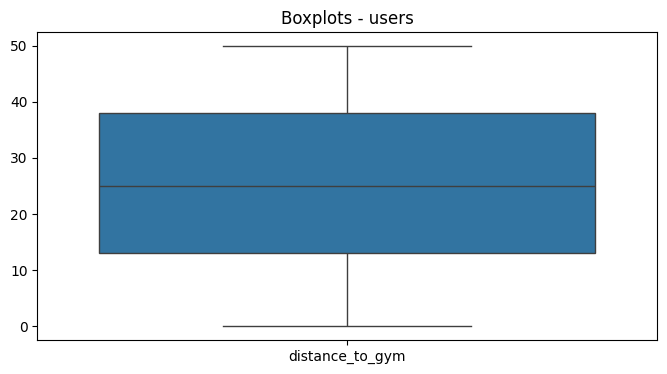

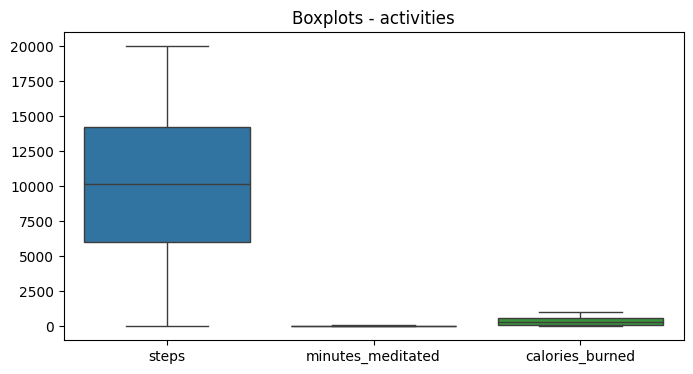

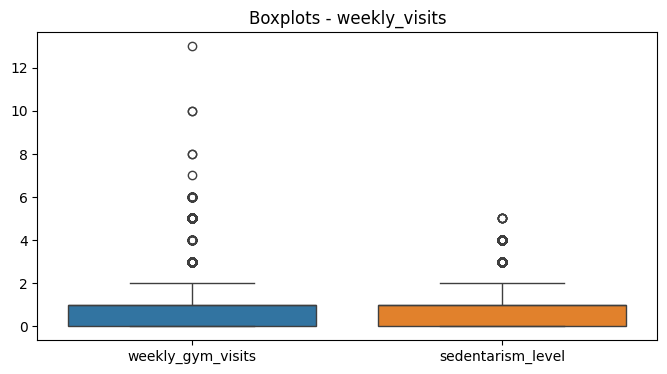

In [133]:
#Verificando possíveis Outliers
os.makedirs('../outputs/', exist_ok=True)

cols_analise = {
    'users': ['distance_to_gym'],
    'activities': ['steps','minutes_meditated','calories_burned'],
    'weekly_visits': ['weekly_gym_visits','sedentarism_level']
}

for name, cols in cols_analise.items():

    df = datasets[name]

    plt.figure(figsize=(8,4))
    
    sns.boxplot(data=df[cols])
    
    plt.title(f'Boxplots - {name}')
    
    file_path = f"../outputs/boxplot_{name}.png"
    
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()
    plt.close()

In [137]:
for name, cols in cols_analise.items():

    df = datasets[name]

    print(f'\n==== Dataset: {name} ====')

    for col in cols:
        min_val = df[col].min()
        max_val = df[col].max()

        print(f'{col}: min = {min_val} | max = {max_val}')



==== Dataset: users ====
distance_to_gym: min = 0.0 | max = 49.89

==== Dataset: activities ====
steps: min = 3 | max = 19999
minutes_meditated: min = 0 | max = 59
calories_burned: min = 10.0 | max = 999.99

==== Dataset: weekly_visits ====
weekly_gym_visits: min = 0 | max = 13
sedentarism_level: min = 0 | max = 5


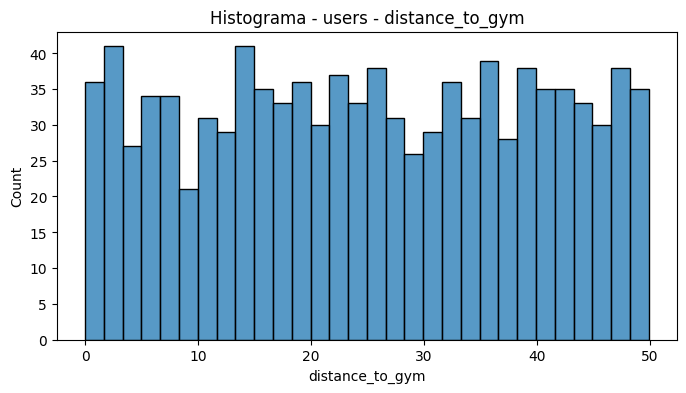

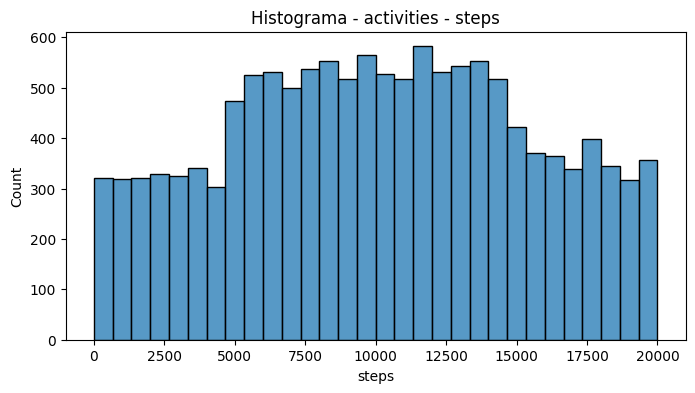

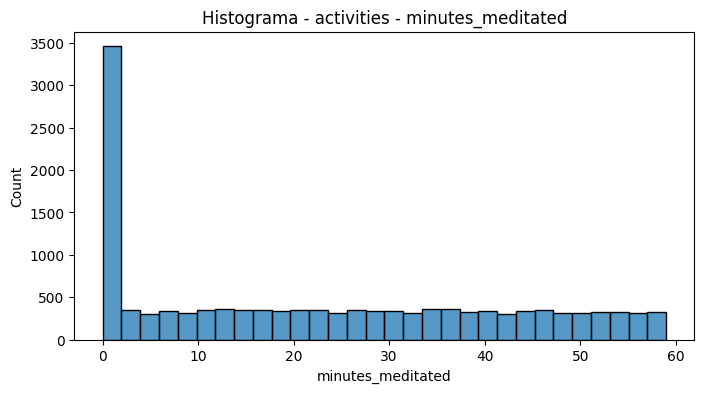

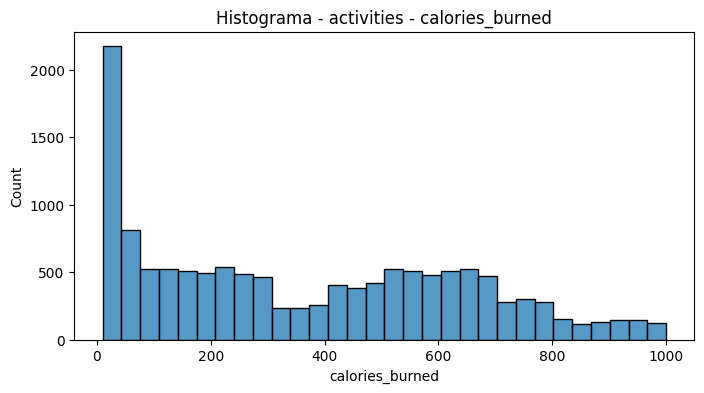

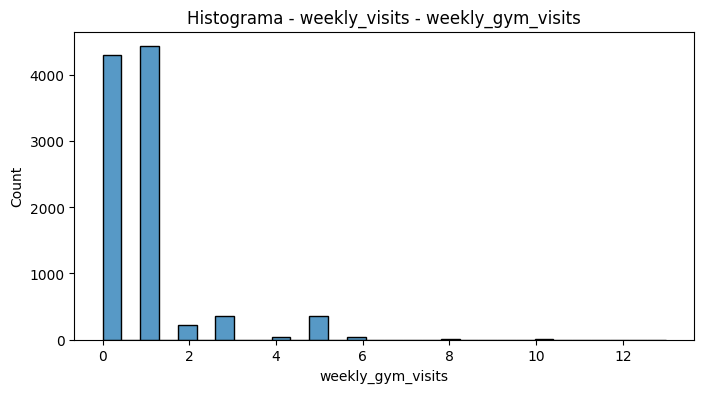

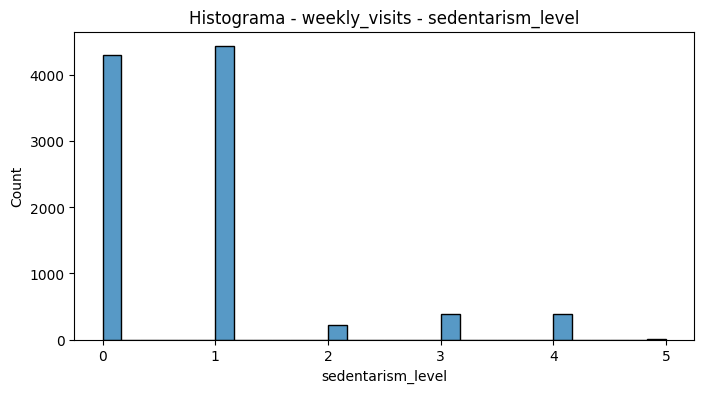

In [135]:
#Verificando a distribuição das variáveis
os.makedirs('../outputs/', exist_ok=True)

for name, cols in cols_analise.items():

    df = datasets[name]

    for col in cols:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], bins=30)
        plt.title(f'Histograma - {name} - {col}')
        file_path = f"../outputs/hist_{name}_{col}.png"
        plt.savefig(file_path, bbox_inches='tight')
        plt.show()
        plt.close()
        